# MNIST Classification

## Load modules

In [1]:
# ============================================
# 1. 필요한 라이브러리 불러오기
# ============================================

# 숫자 계산을 쉽게 하기 위한 라이브러리입니다.
# 배열, 행렬, 난수 처리 등에 많이 사용합니다.
import numpy as np

# 딥러닝 모델을 만들고 학습시키기 위한 라이브러리입니다.
# 여기서는 MNIST 숫자 이미지 분류 모델을 만들 때 사용합니다.
import tensorflow as tf

# 이미지나 그래프를 화면에 보여주기 위한 라이브러리입니다.
# MNIST 손글씨 숫자 이미지를 확인할 때 사용합니다.
import matplotlib.pyplot as plt

# TensorFlow 안에 기본으로 들어 있는 MNIST 데이터셋을 불러옵니다.
# MNIST는 0부터 9까지 손글씨 숫자 이미지 데이터입니다.
from tensorflow.keras.datasets import mnist


# 현재 사용하는 라이브러리 버전을 확인합니다.
# 버전에 따라 코드 실행 결과나 함수 사용 방식이 조금 달라질 수 있기 때문입니다.
print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.16.2
Matplotlib Version :3.10.0


## Load MNIST Data

In [2]:
# ============================================
# 2. MNIST 데이터 불러오기
# ============================================

# mnist.load_data()는 학습용 데이터와 테스트용 데이터를 나누어서 가져옵니다.
# train_data는 학습에 사용할 이미지 데이터입니다.
# train_labels는 학습 이미지의 정답입니다.
# test_data는 학습이 끝난 뒤 모델을 평가할 이미지 데이터입니다.
# test_labels는 테스트 이미지의 정답입니다.

(train_data, train_labels), (test_data, test_labels) = mnist.load_data()


# ============================================
# 3. 데이터 모양 확인하기
# ============================================

# train_data의 자료형을 확인합니다.
# 보통 numpy 배열 형태입니다.
print("Type : {}".format(type(train_data)))

# train_data의 모양을 확인합니다.
# MNIST 학습 데이터는 보통 (60000, 28, 28)입니다.
# 의미는 28x28 크기의 이미지가 60000장 있다는 뜻입니다.
print("Shape : {}".format(train_data.shape))


# test_data의 자료형을 확인합니다.
print("Type : {}".format(type(test_data)))

# test_data의 모양을 확인합니다.
# MNIST 테스트 데이터는 보통 (10000, 28, 28)입니다.
# 의미는 28x28 크기의 이미지가 10000장 있다는 뜻입니다.
print("Shape : {}".format(test_data.shape))


# train_labels의 자료형을 확인합니다.
print("Type : {}".format(type(train_labels)))

# train_labels의 모양을 확인합니다.
# 보통 (60000,)입니다.
# 이미지 60000장 각각에 정답 숫자 하나씩 붙어 있다는 뜻입니다.
print("Shape : {}".format(train_labels.shape))


# test_labels의 자료형을 확인합니다.
print("Type : {}".format(type(test_labels)))

# test_labels의 모양을 확인합니다.
# 보통 (10000,)입니다.
# 테스트 이미지 10000장 각각에 정답 숫자 하나씩 붙어 있다는 뜻입니다.
print("Shape : {}".format(test_labels.shape))

Type : <class 'numpy.ndarray'>
Shape : (60000, 28, 28)
Type : <class 'numpy.ndarray'>
Shape : (10000, 28, 28)
Type : <class 'numpy.ndarray'>
Shape : (60000,)
Type : <class 'numpy.ndarray'>
Shape : (10000,)


## Show Train/Test data, labels

In [3]:
# ============================================
# 4. 실제 이미지 데이터 값 확인하기
# ============================================

# train_data를 출력하면 이미지가 숫자 배열로 저장되어 있는 것을 볼 수 있습니다.
# 각 이미지는 28행 28열의 숫자로 이루어져 있습니다.
# 숫자 하나는 픽셀 하나의 밝기를 의미합니다.
# 0은 검은색에 가깝고, 255는 흰색에 가깝습니다.
train_data

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

## 예시 이미지 

<img src="https://hatchworks.com/wp-content/uploads/2024/09/llm-number-6-1024x990.png" width="500">

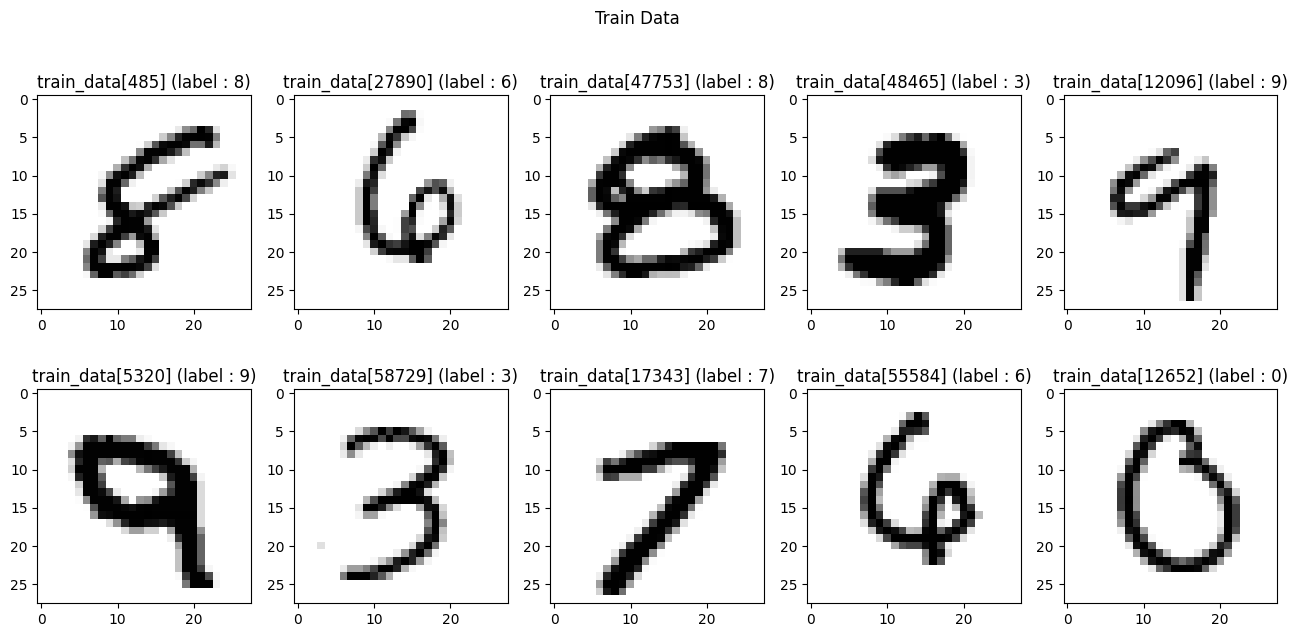

In [4]:
# ============================================
# 5. 학습 이미지 중 일부를 화면에 보여주기
# ============================================

# train_data.shape[0]은 학습 이미지의 전체 개수입니다.
# MNIST에서는 보통 60000입니다.
# np.arange(0, train_data.shape[0])는 0부터 59999까지의 번호를 만듭니다.
idx_show = np.arange(0, train_data.shape[0])

# 이미지 번호를 무작위로 섞습니다.
# 매번 같은 이미지가 아니라 랜덤하게 이미지를 보기 위해 사용합니다.
np.random.shuffle(idx_show)

# 섞인 번호 중 앞에서 10개만 선택합니다.
# 즉, 학습 데이터 중 랜덤으로 10장을 뽑는 것입니다.
idx_show = idx_show[0:10]

# 2행 5열 형태의 그림판을 만듭니다.
# 총 10개의 이미지를 보여주기 위해 2 x 5 구조를 사용합니다.
# figsize는 그림 전체 크기입니다.
fig_train, ax_train = plt.subplots(2, 5, figsize=(16, 7))

# 전체 그림의 제목을 설정합니다.
fig_train.suptitle("Train Data")

# 10개의 이미지를 하나씩 출력합니다.
for idx in range(10):
    
    # idx//5는 행 위치를 의미합니다.
    # idx%5는 열 위치를 의미합니다.
    # 예를 들어 idx가 0이면 [0,0], idx가 4이면 [0,4], idx가 5이면 [1,0] 위치입니다.
    
    # train_data[idx_show[idx]]는 랜덤으로 뽑은 이미지 한 장입니다.
    # cmap="binary"는 이미지를 흑백으로 보여주기 위한 설정입니다.
    ax_train[idx//5, idx%5].imshow(train_data[idx_show[idx]], cmap="binary")
    
    # 각 이미지 위에 제목을 붙입니다.
    # train_data 번호와 실제 정답 label을 함께 보여줍니다.
    # label이 7이면 해당 이미지는 숫자 7이라는 뜻입니다.
    ax_train[idx//5, idx%5].set_title(
        "train_data[{}] (label : {})".format(
            idx_show[idx], 
            train_labels[idx_show[idx]]
        )
    )

## Min Max Scaler

In [5]:
# ============================================
# 6. 데이터 정규화
# ============================================

# 원래 MNIST 이미지의 픽셀 값은 0부터 255 사이입니다.
# 예를 들어 0은 어두운 픽셀, 255는 밝은 픽셀입니다.

# 딥러닝 모델은 너무 큰 숫자보다 0~1 사이의 작은 숫자를 더 안정적으로 학습합니다.
# 그래서 모든 픽셀 값을 255로 나누어 0~1 사이 값으로 바꿉니다.

# 예를 들어 픽셀 값이 255이면 255 / 255 = 1.0이 됩니다.
# 픽셀 값이 128이면 128 / 255 = 약 0.502가 됩니다.
# 픽셀 값이 0이면 0 / 255 = 0.0이 됩니다.

train_data, test_data = train_data / 255.0, test_data / 255.0
train_data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

## Model 정의

In [11]:
# ============================================
# 7. 딥러닝 모델 만들기
# ============================================

# Sequential은 층을 순서대로 쌓는 방식입니다.
# 즉, 입력층 → 은닉층 → 출력층 순서로 데이터가 지나갑니다.

model = tf.keras.models.Sequential([
    
    # 입력 데이터의 모양을 정합니다.
    # MNIST 이미지는 28 x 28 크기입니다.
    # 한 장의 이미지는 28행 28열의 픽셀로 구성되어 있습니다.
    tf.keras.Input(shape=(28, 28)),
    
    
    # Flatten은 2차원 이미지를 1차원 배열로 펼치는 역할을 합니다.
    # 28 x 28 이미지는 총 784개의 픽셀을 가지고 있습니다.
    # 따라서 Flatten을 지나면 (28, 28) 형태가 784개의 숫자 배열로 바뀝니다.
    # Dense 층은 1차원 데이터 입력을 받기 때문에 Flatten이 필요합니다.
    tf.keras.layers.Flatten(),
    
    
    # 첫 번째 은닉층입니다.
    # Dense는 모든 입력 노드와 모든 출력 노드가 연결된 완전연결층입니다.
    # 512는 이 층에 있는 뉴런의 개수입니다.
    # activation='sigmoid'는 활성화 함수로 시그모이드를 사용한다는 뜻입니다.
    # 시그모이드는 값을 0과 1 사이로 바꿔줍니다.
    # 은닉층에서 비선형성을 만들기 위해 사용합니다.
    tf.keras.layers.Dense(16, activation='sigmoid'),
    
    
    # 두 번째 은닉층입니다.
    # 첫 번째 은닉층에서 뽑은 특징을 다시 조합해서 더 복잡한 패턴을 학습합니다.
    # 예를 들어 숫자 3의 곡선, 숫자 8의 닫힌 모양 같은 특징을 학습할 수 있습니다.
    tf.keras.layers.Dense(16, activation='sigmoid'),
    
    
    # 출력층입니다.
    # MNIST는 숫자 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 중 하나를 맞히는 문제입니다.
    # 가능한 정답이 총 10개이므로 출력 뉴런도 10개입니다.
    # activation='softmax'는 10개 숫자 각각에 대한 확률을 계산합니다.
    # 예를 들어 [0.01, 0.02, 0.90, ...]처럼 나오면 모델은 숫자 2일 가능성이 가장 높다고 판단합니다.
    tf.keras.layers.Dense(10, activation='softmax')
])

# 모델의 전체 구조를 출력합니다.
# 각 층의 이름, 출력 형태, 학습해야 하는 파라미터 개수를 확인할 수 있습니다.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

<img src="https://miro.medium.com/v2/resize:fit:1092/format:webp/1*xZVA9NZUQH7t8zSe92onQQ.png" width="500">
<img src="https://miro.medium.com/v2/resize:fit:910/format:webp/1*uh56DdpELgCEeJyePLMDpA.png" width="500">g

## Model compile

In [12]:
# ============================================
# 8. 모델 학습 방법 설정하기
# ============================================

model.compile(
    
    # optimizer는 모델이 틀린 정도를 줄이기 위해 가중치를 어떻게 수정할지 정하는 방법입니다.
    # adam은 많이 사용하는 최적화 알고리즘입니다.
    # 경사하강법을 더 효율적으로 개선한 방식이라고 이해하면 됩니다.
    optimizer='adam',
    
    # loss는 모델의 예측이 정답과 얼마나 다른지 계산하는 기준입니다.
    # sparse_categorical_crossentropy는 다중 분류 문제에서 사용합니다.
    # 여기서는 정답 label이 0, 1, 2처럼 정수 형태이므로 sparse 버전을 사용합니다.
    # 만약 정답이 [0,0,1,0,0,0,0,0,0,0] 같은 원-핫 인코딩이면 categorical_crossentropy를 사용합니다.
    loss='sparse_categorical_crossentropy',
    
    # metrics는 학습 중에 확인할 평가 지표입니다.
    # accuracy는 전체 데이터 중 몇 개를 맞혔는지 비율로 보여줍니다.
    metrics=['accuracy']
)

## 학습 (Training)

In [13]:
# ============================================
# 9. TensorFlow 실행 환경 확인하기
# ============================================

# TensorFlow 버전을 다시 확인합니다.
print("TensorFlow version:", tf.__version__)

# 현재 컴퓨터에서 TensorFlow가 사용할 수 있는 장치들을 확인합니다.
# CPU, GPU 등이 표시될 수 있습니다.
print("Physical devices:", tf.config.list_physical_devices())

# GPU가 잡혀 있는지 따로 확인합니다.
# GPU가 있으면 딥러닝 학습이 더 빠르게 실행될 수 있습니다.
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.16.2
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
# ============================================
# 10. 모델 학습시키기
# ============================================

# model.fit은 모델을 실제로 학습시키는 명령어입니다.
# train_data는 입력 이미지입니다.
# train_labels는 각 이미지의 정답입니다.
# epochs=10은 전체 학습 데이터를 10번 반복해서 학습한다는 뜻입니다.

# 예를 들어 학습 데이터 60000장을 한 번 모두 보면 1 epoch입니다.
# epochs=10이면 60000장을 총 10번 반복해서 보는 것입니다.

history = model.fit(train_data, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7512 - loss: 1.1304
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8974 - loss: 0.4163
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9182 - loss: 0.3012
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9301 - loss: 0.2527
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9381 - loss: 0.2229
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9432 - loss: 0.2031
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9468 - loss: 0.1877
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9491 - loss: 0.1761
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9528 - loss: 0.1668
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9543 - loss: 0.1593


## Training 결과 Test

In [16]:
# ============================================
# 11. 테스트 데이터로 모델 평가하기
# ============================================

# 학습에 사용하지 않은 test_data로 모델 성능을 확인합니다.
# 이것이 중요한 이유는 모델이 단순히 학습 데이터를 외운 것인지,
# 아니면 새로운 데이터도 잘 맞히는지 확인해야 하기 때문입니다.

# model.evaluate는 loss와 accuracy를 출력합니다.
# loss는 낮을수록 좋습니다.
# accuracy는 높을수록 좋습니다.

# %%time은 이 셀을 실행하는 데 걸린 시간을 보여줍니다.
# Jupyter Notebook에서만 사용할 수 있는 명령어입니다.

model.evaluate(test_data, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9486 - loss: 0.1735


[0.17346400022506714, 0.9485999941825867]

256,256 layer,
[0.08279715478420258, 0.9760000109672546],

256,512 layer.
[0.06932496279478073, 0.9776999950408936]

512,512 layer.
[0.08406271040439606, 0.9764000177383423]

512,512 layer. ephoc 10
[0.08406271040439606, 0.9764000177383423]


핵심은 이 코드가 “28x28 손글씨 이미지를 입력받아, 그 이미지가 0부터 9 중 어떤 숫자인지 분류하는 모델”이라는 점입니다.
Flatten은 이미지를 Dense 층에 넣기 위해 1차원으로 펼치는 과정입니다. Dense 512층 두 개는 이미지 속 숫자의 특징을 학습하는 부분입니다. 마지막 Dense 10층은 숫자 0부터 9까지 각각의 가능성을 출력하는 부분입니다. Softmax는 그 10개의 값을 확률처럼 바꿔서, 가장 가능성이 높은 숫자를 선택할 수 있게 해주는 역할입니다.